In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
# 1. Custom Prunable Linear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weights and bias
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Gate scores: same shape as weight, registered as parameter
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.constant_(self.bias, 0)
        # Start gates near 1 (Sigmoid(0.0) ≈ 0.5) so training begins dense
        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x):
        # Transform scores to gates (0-1)
        gates = torch.sigmoid(self.gate_scores)

        # Element-wise multiplication for pruning
        pruned_weights = self.weight * gates

        # Standard linear operation with pruned weights
        return F.linear(x, pruned_weights, self.bias)

In [4]:
# 2. Neural Network Definition
class SelfPruningMLP(nn.Module):
    def __init__(self):
        super(SelfPruningMLP, self).__init__()
        self.flatten = nn.Flatten()
        # 3-layer architecture for CIFAR-10 classification
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_gates(self):
        # Helper to retrieve all active gates for loss and analysis
        return [torch.sigmoid(self.fc1.gate_scores),
                torch.sigmoid(self.fc2.gate_scores),
                torch.sigmoid(self.fc3.gate_scores)]

In [5]:
def evaluate_performance(model, loader, device, threshold=1e-2):
    model.eval()
    correct = 0
    total = 0

    # Track Inference Latency
    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    end_time = time.time()
    latency = (end_time - start_time) / len(loader) * 1000  # ms per batch
    accuracy = 100 * correct / total

    # Calculate Sparsity & Parameter Statistics
    all_gates = []
    for g in model.get_gates():
        all_gates.extend(g.cpu().detach().numpy().flatten())

    gate_array = np.array(all_gates)
    active_params = np.sum(gate_array >= threshold)
    total_params = len(gate_array)
    sparsity_level = (1 - (active_params / total_params)) * 100

    return accuracy, sparsity_level, latency, active_params, gate_array

In [6]:
# 4. Training Loop
def run_experiment(lambda_val, epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Data Loading
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

    model = SelfPruningMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"\nTraining with Lambda: {lambda_val}...")
    for epoch in range(epochs):
        model.train()
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            class_loss = criterion(outputs, labels)

            # Sparsity Regularization: L1 Norm of gates
            sparsity_loss = sum([torch.sum(torch.abs(g)) for g in model.get_gates()])

            total_loss = class_loss + lambda_val * sparsity_loss
            total_loss.backward()
            optimizer.step()

    # Final detailed evaluation
    return evaluate_performance(model, testloader, device)

In [7]:
# 5. Main Execution Loop
lambdas = [1e-4, 1e-3, 5e-3]
final_results = []

for l in lambdas:
    acc, sparse, lat, active, gates = run_experiment(l)
    final_results.append({
        "Lambda": l,
        "Accuracy": acc,
        "Sparsity": sparse,
        "Latency": lat,
        "Active": active,
        "Gate_Data": gates
    })

# 6. Final Results Report Generation
print("\n" + "="*85)
print(f"{'Lambda':<10} | {'Acc (%)':<10} | {'Sparsity (%)':<15} | {'Active Params':<15} | {'Latency (ms)':<10}")
print("-" * 85)
for res in final_results:
    print(f"{res['Lambda']:<10} | {res['Accuracy']:<10.2f} | {res['Sparsity']:<15.2f} | {res['Active']:<15} | {res['Latency']:<10.2f}")
print("="*85)

100%|██████████| 170M/170M [00:06<00:00, 26.2MB/s]



Training with Lambda: 0.0001...

Training with Lambda: 0.001...

Training with Lambda: 0.005...

Lambda     | Acc (%)    | Sparsity (%)    | Active Params   | Latency (ms)
-------------------------------------------------------------------------------------
0.0001     | 56.65      | 81.00           | 324254          | 15.33     
0.001      | 52.74      | 99.58           | 7156            | 14.44     
0.005      | 46.11      | 99.94           | 1035            | 14.39     


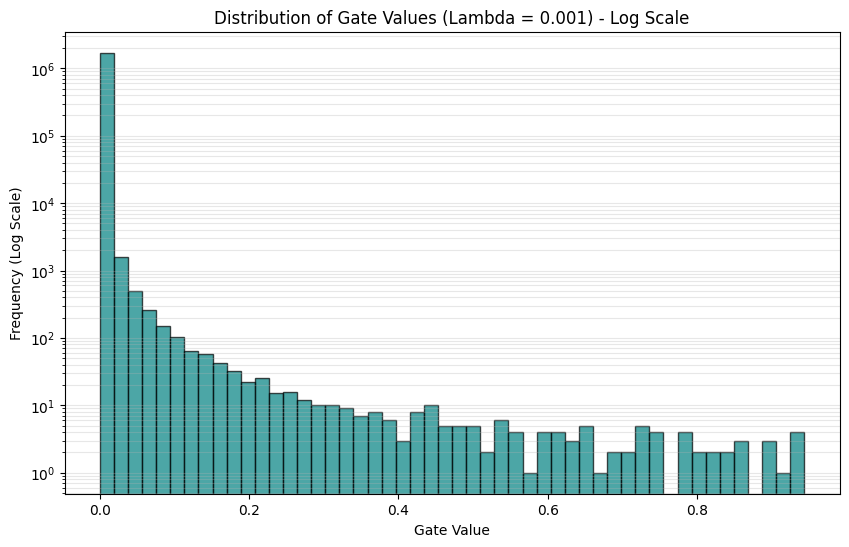

In [10]:
# Plotting distribution for middle lambda
plt.figure(figsize=(10, 6))
# Use log=True inside the hist function
plt.hist(final_results[1]['Gate_Data'], bins=50, color='teal', edgecolor='black', alpha=0.7, log=True)
plt.title(f"Distribution of Gate Values (Lambda = {final_results[1]['Lambda']}) - Log Scale")
plt.xlabel("Gate Value")
plt.ylabel("Frequency (Log Scale)")
plt.grid(axis='y', alpha=0.3, which='both')
plt.show()